In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS - PV MICROGRID FORECASTING
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import warnings
warnings.filterwarnings('ignore')

print("Imports ολοκληρώθηκαν")

Mounted at /content/drive
Imports ολοκληρώθηκαν


In [ ]:
# ============================================================
# CELL 2: ΦΟΡΤΩΣΗ DATASETS & ΣΥΓΧΡΟΝΙΣΜΟΣ
# ============================================================

paths = {
    'BESS':        '/content/drive/MyDrive/Final_RUn/239-Site_DKA_Totals-BESS.csv',
    'Site_Demand': '/content/drive/MyDrive/Final_RUn/240-Site_DKA_Totals-Site_Demand.csv',
    'PV':          '/content/drive/MyDrive/Final_RUn/241-Site_DKA_Totals-PV.csv',
    'Grid':        '/content/drive/MyDrive/Final_RUn/242-Site_DKA_Totals-Grid.csv'
}

datasets = {}
for name, path in paths.items():
    df_temp = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'], errors='coerce')
    df_temp = df_temp.dropna(subset=['timestamp'])
    df_temp = df_temp.set_index('timestamp').sort_index()
    datasets[name] = df_temp
    print(f"{name}: {len(df_temp):,} γραμμές")

# Κοινό date range
common_start = max(df.index.min() for df in datasets.values())
common_end = min(df.index.max() for df in datasets.values())

for name in datasets:
    datasets[name] = datasets[name].loc[common_start:common_end]

print(f"\nΚοινό date range: {common_start} έως {common_end}")
print(f"Διάρκεια: {(common_end - common_start).days} ημέρες")

BESS: 250,740 γραμμές
Site_Demand: 182,349 γραμμές
PV: 182,295 γραμμές
Grid: 182,289 γραμμές

Κοινό date range: 2023-12-07 13:20:00 έως 2025-09-04 12:10:00
Διάρκεια: 636 ημέρες


In [ ]:
# ============================================================
# CELL 3: ΕΝΙΑΙΟ DATAFRAME ΓΙΑ PV FORECASTING
# ============================================================

# Ξεκινάμε από PV (target)
df = pd.DataFrame(index=datasets['PV'].index)

# Target
df['PV_Power'] = datasets['PV']['Active_Power']

# Weather features (από PV CSV - είναι ίδια σε όλα)
weather_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]
for col in weather_cols:
    df[col] = datasets['PV'][col]

print(f"Συνολικό dataframe: {df.shape}")
print(f"\nΣτήλες:")
for col in df.columns:
    print(f"  - {col}")

Συνολικό dataframe: (182293, 5)

Στήλες:
  - PV_Power
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation


In [ ]:
# ============================================================
# CELL 4: BASIC CLEANING
# ============================================================

print("="*70)
print(" BASIC CLEANING")
print("="*70)

initial = len(df)

# 1. PV: μικρές αρνητικές → 0 (inverter standby), μεγάλες → NaN
small_neg = ((df['PV_Power'] < 0) & (df['PV_Power'] > -10)).sum()
big_neg = (df['PV_Power'] < -10).sum()
print(f"Μικρές αρνητικές PV (-10 < x < 0): {small_neg} -> 0")
print(f"Μεγάλες αρνητικές PV (< -10): {big_neg} -> NaN")
df.loc[(df['PV_Power'] < 0) & (df['PV_Power'] > -10), 'PV_Power'] = 0
df.loc[df['PV_Power'] < -10, 'PV_Power'] = np.nan

# 2. Humidity > 100% → clip
high_hum = (df['Weather_Relative_Humidity'] > 100).sum()
print(f"Humidity > 100%: {high_hum} -> clip στο 100")
df['Weather_Relative_Humidity'] = df['Weather_Relative_Humidity'].clip(0, 100)

# 3. Negative radiation values (sensor errors)
for rad_col in ['Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']:
    neg_rad = (df[rad_col] < 0).sum()
    if neg_rad > 0:
        print(f"Αρνητικές τιμές {rad_col}: {neg_rad} -> 0")
        df.loc[df[rad_col] < 0, rad_col] = 0

print(f"\nMissing values:")
for col in df.columns:
    n_missing = df[col].isnull().sum()
    pct = n_missing / len(df) * 100
    print(f"  {col:<40} {n_missing:>8,} ({pct:.1f}%)")

 BASIC CLEANING
Μικρές αρνητικές PV (-10 < x < 0): 86155 -> 0
Μεγάλες αρνητικές PV (< -10): 0 -> NaN
Humidity > 100%: 3683 -> clip στο 100

Missing values:
  PV_Power                                   16,934 (9.3%)
  Weather_Temperature_Celsius                36,289 (19.9%)
  Weather_Relative_Humidity                  36,285 (19.9%)
  Global_Horizontal_Radiation                36,270 (19.9%)
  Diffuse_Horizontal_Radiation               36,270 (19.9%)


 OUTAGE DETECTION FOR PV
Outage detection: GHI > 100 W/m² αλλά PV < 5 kW
Outage observations: 156 (0.09%)


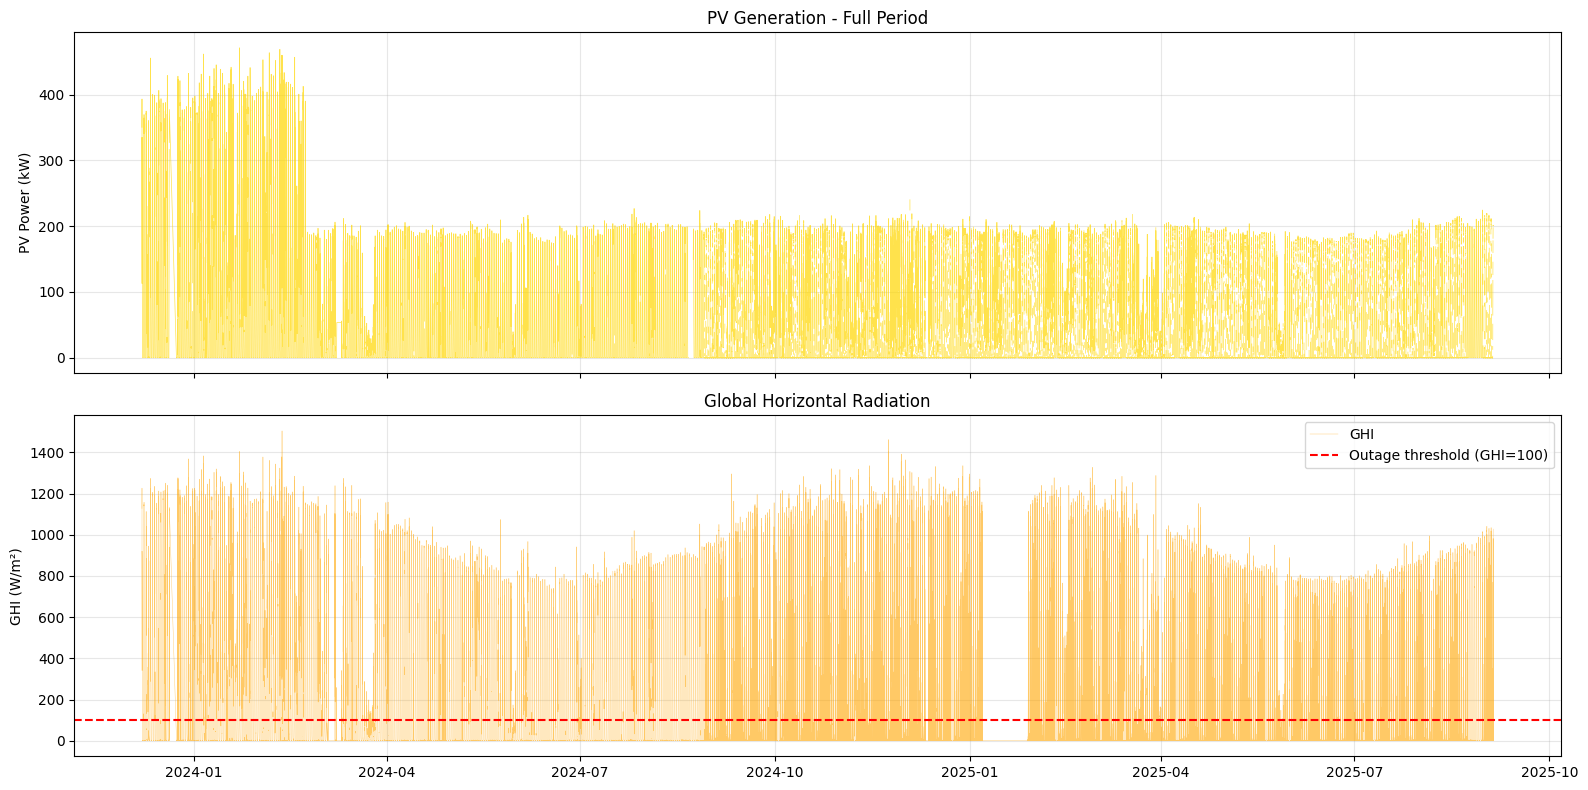


Μετά outage removal:
  PV_Power missing: 17,090


In [ ]:
# ============================================================
# CELL 5: OUTAGE DETECTION (PV-SPECIFIC)
# ============================================================

print("="*70)
print(" OUTAGE DETECTION FOR PV")
print("="*70)

# Στρατηγική: PV outage = όταν έχει ηλιοφάνεια αλλά PV=0
# Δηλαδή: GHI > 100 W/m² αλλά PV_Power < 5 kW

# Πρώτα γεμίζουμε τα NaN GHI με 0 για να αποφύγουμε false positives
ghi_filled = df['Global_Horizontal_Radiation'].fillna(0)

# Outage condition: ηλιοφάνεια χωρίς PV παραγωγή
outage_mask = (ghi_filled > 100) & (df['PV_Power'] < 5)
n_outage = outage_mask.sum()
print(f"Outage detection: GHI > 100 W/m² αλλά PV < 5 kW")
print(f"Outage observations: {n_outage:,} ({n_outage/len(df)*100:.2f}%)")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df['PV_Power'], color='gold', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('PV Power (kW)')
axes[0].set_title('PV Generation - Full Period')
axes[0].grid(alpha=0.3)

axes[1].plot(df.index, ghi_filled, color='orange', linewidth=0.3, alpha=0.6,
             label='GHI')
axes[1].axhline(y=100, color='red', linestyle='--', label='Outage threshold (GHI=100)')
axes[1].set_ylabel('GHI (W/m²)')
axes[1].set_title('Global Horizontal Radiation')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pv_outage_detection.png', dpi=120, bbox_inches='tight')
plt.show()

# Αντιμετώπιση
df.loc[outage_mask, 'PV_Power'] = np.nan

print(f"\nΜετά outage removal:")
print(f"  PV_Power missing: {df['PV_Power'].isnull().sum():,}")

 PV BEHAVIOR CHANGE INVESTIGATION

Μηνιαία στατιστικά PV_Power:
                   max        mean  count   count_pct
year_month                                           
2023-12     455.626770  109.394299   5948   66.726498
2024-01     471.184540  102.594382   8868   99.483958
2024-02     468.956818   91.335521   8346   93.628001
2024-03     211.702240   38.845603   8910   99.955127
2024-04     205.744095   54.060449   8516   95.535113
2024-05     209.554596   46.796237   8903   99.876599
2024-06     216.714188   45.325642   8629   96.802782
2024-07     226.865005   51.489813   8914  100.000000
2024-08     223.899277   55.844462   8137   91.283374
2024-09     219.559052   52.650225   7507   84.215840
2024-10     216.300888   54.372099   8026   90.038142
2024-11     217.719162   48.326245   7857   88.142248
2024-12     240.193085   51.328084   7720   86.605340
2025-01     210.269928   57.295591   7420   83.239847
2025-02     207.516846   55.223355   6439   72.234687
2025-03     217.91

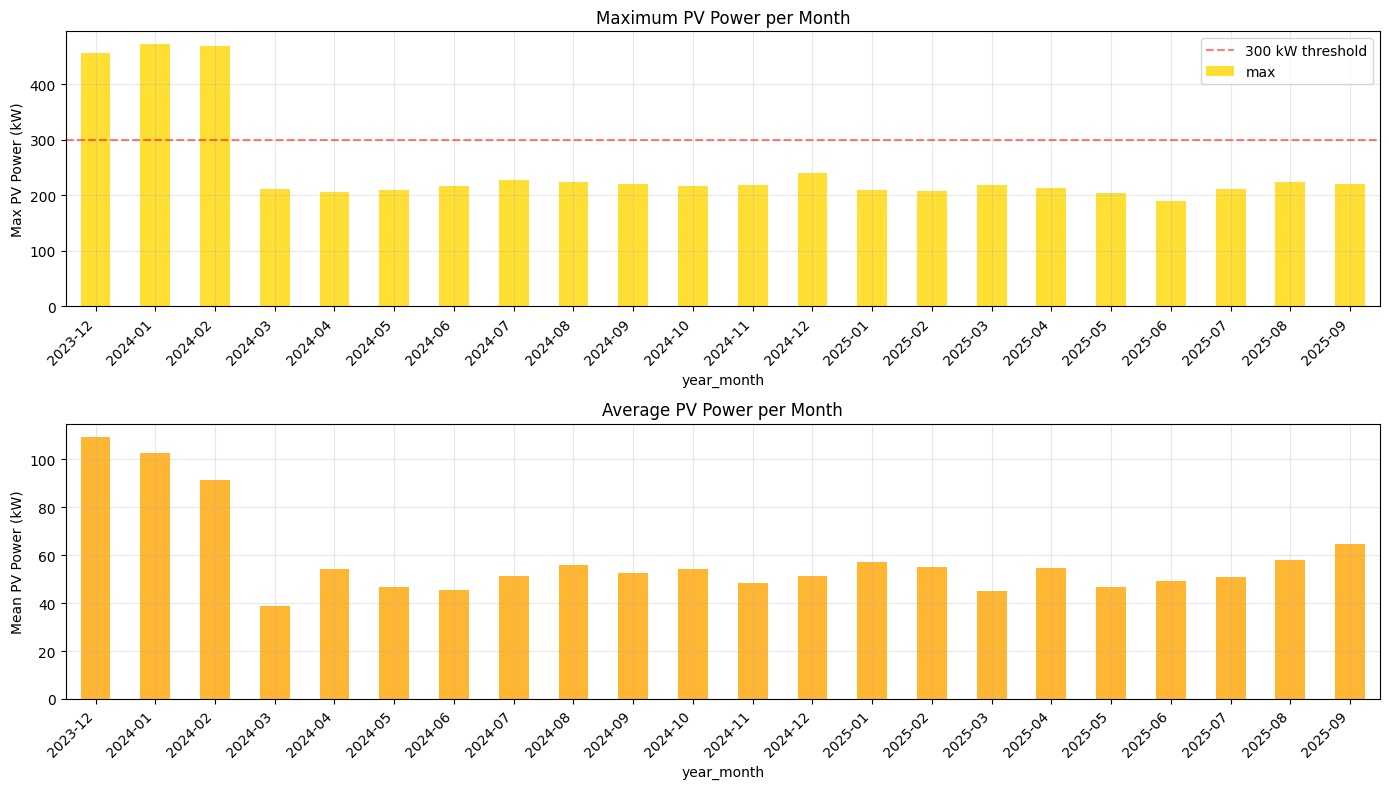


=== CHANGE POINT ANALYSIS ===
Πριν τον Μάρτιο 2024 (Dec 2023 - Feb 2024):
  Max:  471.2 kW
  Mean: 100.3 kW

Από τον Μάρτιο 2024 και μετά:
  Max:  240.2 kW
  Mean: 50.9 kW

Μείωση max: 49.0%


In [ ]:
# ============================================================
# CELL 5b: ΔΙΕΡΕΥΝΗΣΗ ΑΛΛΑΓΗΣ PV ΣΥΜΠΕΡΙΦΟΡΑΣ
# ============================================================

print("="*70)
print(" PV BEHAVIOR CHANGE INVESTIGATION")
print("="*70)

# Μηνιαία max και mean PV
df_temp = df.copy()
df_temp['year_month'] = df_temp.index.to_period('M')

monthly_pv = df_temp.groupby('year_month')['PV_Power'].agg(['max', 'mean', 'count'])
monthly_pv['count_pct'] = monthly_pv['count'] / monthly_pv['count'].max() * 100

print("\nΜηνιαία στατιστικά PV_Power:")
print(monthly_pv.to_string())

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

monthly_pv['max'].plot(kind='bar', ax=axes[0], color='gold', alpha=0.8)
axes[0].set_ylabel('Max PV Power (kW)')
axes[0].set_title('Maximum PV Power per Month')
axes[0].axhline(y=300, color='red', linestyle='--', alpha=0.5, label='300 kW threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

monthly_pv['mean'].plot(kind='bar', ax=axes[1], color='orange', alpha=0.8)
axes[1].set_ylabel('Mean PV Power (kW)')
axes[1].set_title('Average PV Power per Month')
axes[1].grid(alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pv_monthly_change.png', dpi=120, bbox_inches='tight')
plt.show()

# Εντοπισμός του change point
print(f"\n=== CHANGE POINT ANALYSIS ===")
print(f"Πριν τον Μάρτιο 2024 (Dec 2023 - Feb 2024):")
before_change = df['2023-12-07':'2024-02-29']['PV_Power']
print(f"  Max:  {before_change.max():.1f} kW")
print(f"  Mean: {before_change.mean():.1f} kW")

print(f"\nΑπό τον Μάρτιο 2024 και μετά:")
after_change = df['2024-03-01':]['PV_Power']
print(f"  Max:  {after_change.max():.1f} kW")
print(f"  Mean: {after_change.mean():.1f} kW")

print(f"\nΜείωση max: {(1 - after_change.max()/before_change.max())*100:.1f}%")

In [ ]:
# ============================================================
# CELL 5c: ΦΙΛΤΡΑΡΙΣΜΑ ΣΕ POST-MARCH 2024 PERIOD
# ============================================================

print("="*70)
print(" ΦΙΛΤΡΑΡΙΣΜΑ DATASET - POST MARCH 2024")
print("="*70)

before = len(df)
print(f"\nΑρχικό dataset: {before:,} γραμμές")
print(f"Date range: {df.index.min()} έως {df.index.max()}")

# Filter
CUTOFF_DATE = '2024-03-01'
df = df.loc[CUTOFF_DATE:].copy()

after = len(df)
print(f"\nΦιλτραρισμένο dataset (από {CUTOFF_DATE}):")
print(f"Γραμμές: {after:,}")
print(f"Αφαιρέθηκαν: {before - after:,} ({(before-after)/before*100:.1f}%)")
print(f"Date range: {df.index.min()} έως {df.index.max()}")
print(f"Διάρκεια: {(df.index.max() - df.index.min()).days} ημέρες")

# Έλεγχος consistency μετά το filter
print(f"\n--- PV STATS ΜΕΤΑ ΤΟ FILTER ---")
print(f"Min:  {df['PV_Power'].min():.2f} kW")
print(f"Max:  {df['PV_Power'].max():.2f} kW")
print(f"Mean: {df['PV_Power'].mean():.2f} kW")
print(f"Std:  {df['PV_Power'].std():.2f} kW")

# Επανέλεγχος missing values
print(f"\nMissing values μετά το filter:")
for col in df.columns:
    n_missing = df[col].isnull().sum()
    pct = n_missing / len(df) * 100
    print(f"  {col:<40} {n_missing:>8,} ({pct:.1f}%)")

 ΦΙΛΤΡΑΡΙΣΜΑ DATASET - POST MARCH 2024

Αρχικό dataset: 182,293 γραμμές
Date range: 2023-12-07 13:20:00 έως 2025-09-04 12:10:00

Φιλτραρισμένο dataset (από 2024-03-01):
Γραμμές: 159,085
Αφαιρέθηκαν: 23,208 (12.7%)
Date range: 2024-03-01 00:00:00 έως 2025-09-04 12:10:00
Διάρκεια: 552 ημέρες

--- PV STATS ΜΕΤΑ ΤΟ FILTER ---
Min:  0.00 kW
Max:  240.19 kW
Mean: 50.85 kW
Std:  70.44 kW

Missing values μετά το filter:
  PV_Power                                   17,044 (10.7%)
  Weather_Temperature_Celsius                36,251 (22.8%)
  Weather_Relative_Humidity                  36,247 (22.8%)
  Global_Horizontal_Radiation                36,232 (22.8%)
  Diffuse_Horizontal_Radiation               36,232 (22.8%)


In [ ]:
# ============================================================
# CELL 6: FEATURE ENGINEERING (PV-SPECIFIC)
# ============================================================

print("="*70)
print(" FEATURE ENGINEERING FOR PV")
print("="*70)

# 1. Cyclical time features
# ΣΗΜΑΝΤΙΚΟ: Για PV ΔΕΝ χρειαζόμαστε day_of_week (MI ≈ 0)
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
print("Cyclical features: hour_sin/cos, month_sin/cos")
print("(Drop dow_sin/cos - MI ≈ 0 για PV)")

# 2. Lag features για το target (PV_Power)
# PV: πιο short-term lags γιατί έχει υψηλή volatility (συννεφιά)
df['pv_lag_5min']  = df['PV_Power'].shift(1)    # 5 λεπτά πριν
df['pv_lag_15min'] = df['PV_Power'].shift(3)    # 15 λεπτά πριν
df['pv_lag_30min'] = df['PV_Power'].shift(6)    # 30 λεπτά πριν
df['pv_lag_1h']    = df['PV_Power'].shift(12)   # 1 ώρα πριν
df['pv_lag_24h']   = df['PV_Power'].shift(288)  # 1 μέρα πριν (ίδια ώρα)
print("Lag features: pv_lag_5min, 15min, 30min, 1h, 24h")

# 3. Rolling statistics (μη-leakage με shift)
df['pv_rolling_mean_30min'] = df['PV_Power'].rolling(window=6, min_periods=1).mean().shift(6)
df['pv_rolling_std_30min']  = df['PV_Power'].rolling(window=6, min_periods=1).std().shift(6)
df['pv_rolling_mean_1h']    = df['PV_Power'].rolling(window=12, min_periods=1).mean().shift(12)
print("Rolling features: 30min mean/std, 1h mean")

# 4. Συνολικός κατάλογος
print(f"\nΣυνολικά features: {len(df.columns)}")
for col in df.columns:
    print(f"  - {col}")

 FEATURE ENGINEERING FOR PV
Cyclical features: hour_sin/cos, month_sin/cos
(Drop dow_sin/cos - MI ≈ 0 για PV)
Lag features: pv_lag_5min, 15min, 30min, 1h, 24h
Rolling features: 30min mean/std, 1h mean

Συνολικά features: 17
  - PV_Power
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation
  - hour_sin
  - hour_cos
  - month_sin
  - month_cos
  - pv_lag_5min
  - pv_lag_15min
  - pv_lag_30min
  - pv_lag_1h
  - pv_lag_24h
  - pv_rolling_mean_30min
  - pv_rolling_std_30min
  - pv_rolling_mean_1h


In [ ]:
# ============================================================
# CELL 7: FINAL DATASET PREPARATION
# ============================================================

print("="*70)
print(" FINAL DATASET PREPARATION")
print("="*70)

print(f"\nΑρχικό shape: {df.shape}")

# 1. Drop rows όπου το target είναι NaN
before = len(df)
df = df.dropna(subset=['PV_Power'])
print(f"Drop rows με NaN target (PV_Power): {before - len(df):,} γραμμές")
print(f"Μετά: {df.shape}")

# 2. KNN Imputation για τα weather features
features_to_impute = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]

print(f"\nKNN Imputation (5 neighbors, distance-weighted)...")
print(f"Στήλες προς imputation: {features_to_impute}")

z_scaler = StandardScaler()
data_normalized = z_scaler.fit_transform(df[features_to_impute])

imputer = KNNImputer(n_neighbors=5, weights='distance')
data_imputed = imputer.fit_transform(data_normalized)

df[features_to_impute] = z_scaler.inverse_transform(data_imputed)

print("Imputation ολοκληρώθηκε")

# 3. Drop rows όπου τα lag features είναι NaN
lag_cols = ['pv_lag_5min', 'pv_lag_15min', 'pv_lag_30min',
            'pv_lag_1h', 'pv_lag_24h',
            'pv_rolling_mean_30min', 'pv_rolling_std_30min', 'pv_rolling_mean_1h']

before = len(df)
df = df.dropna(subset=lag_cols)
print(f"\nDrop rows με NaN lag features: {before - len(df):,} γραμμές")
print(f"(αυτές είναι κυρίως οι πρώτες 24h)")

# 4. Final check
print(f"\n--- FINAL DATASET ---")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} έως {df.index.max()}")
print(f"Διάρκεια: {(df.index.max() - df.index.min()).days} ημέρες")
print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ΚΑΝΕΝΑ missing value!")
else:
    print(missing[missing > 0])

# Στατιστικά PV
print(f"\n--- PV STATS ---")
print(f"Min:  {df['PV_Power'].min():.2f} kW")
print(f"Max:  {df['PV_Power'].max():.2f} kW")
print(f"Mean: {df['PV_Power'].mean():.2f} kW")
print(f"% zeros (νυχτερινές):  {(df['PV_Power'] == 0).sum() / len(df) * 100:.1f}%")

 FINAL DATASET PREPARATION

Αρχικό shape: (159085, 17)
Drop rows με NaN target (PV_Power): 17,044 γραμμές
Μετά: (142041, 17)

KNN Imputation (5 neighbors, distance-weighted)...
Στήλες προς imputation: ['Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']
Imputation ολοκληρώθηκε

Drop rows με NaN lag features: 47,825 γραμμές
(αυτές είναι κυρίως οι πρώτες 24h)

--- FINAL DATASET ---
Shape: (94216, 17)
Date range: 2024-03-02 00:00:00 έως 2025-09-04 11:40:00
Διάρκεια: 551 ημέρες

Missing values:
  ΚΑΝΕΝΑ missing value!

--- PV STATS ---
Min:  0.00 kW
Max:  226.87 kW
Mean: 50.43 kW
% zeros (νυχτερινές):  53.3%


In [ ]:
# ============================================================
# CELL 8: TRAIN/TEST SPLIT & FEATURE SELECTION
# ============================================================

print("="*70)
print(" TRAIN/TEST SPLIT & FEATURE SELECTION")
print("="*70)

# Επιλογή final features
target_col = 'PV_Power'
feature_cols = [
    # Weather features (κύρια για PV)
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    # Cyclical features (για ώρα/εποχή)
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    # Lag features (κρίσιμα για short-term forecasting)
    'pv_lag_5min', 'pv_lag_15min', 'pv_lag_30min',
    'pv_lag_1h', 'pv_lag_24h',
    # Rolling statistics
    'pv_rolling_mean_30min', 'pv_rolling_std_30min', 'pv_rolling_mean_1h'
]

print(f"Target: {target_col}")
print(f"Features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Χρονολογικός διαχωρισμός 80/20
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"\n--- TRAIN/TEST SPLIT ---")
print(f"Train: {len(train_df):,} γραμμές ({train_df.index.min()} έως {train_df.index.max()})")
print(f"Test:  {len(test_df):,} γραμμές ({test_df.index.min()} έως {test_df.index.max()})")
print(f"Test διάρκεια: {(test_df.index.max() - test_df.index.min()).days} ημέρες")

# Min-Max Normalization
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[feature_cols])
y_train = scaler_y.fit_transform(train_df[[target_col]]).flatten()

X_test = scaler_X.transform(test_df[feature_cols])
y_test = scaler_y.transform(test_df[[target_col]]).flatten()

target_min = scaler_y.data_min_[0]
target_max = scaler_y.data_max_[0]

y_test_kw = test_df[target_col].values

print(f"\n--- SHAPES ---")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nTarget range στο training: {target_min:.2f} - {target_max:.2f} kW")

 TRAIN/TEST SPLIT & FEATURE SELECTION
Target: PV_Power
Features (16):
   1. Global_Horizontal_Radiation
   2. Diffuse_Horizontal_Radiation
   3. Weather_Temperature_Celsius
   4. Weather_Relative_Humidity
   5. hour_sin
   6. hour_cos
   7. month_sin
   8. month_cos
   9. pv_lag_5min
  10. pv_lag_15min
  11. pv_lag_30min
  12. pv_lag_1h
  13. pv_lag_24h
  14. pv_rolling_mean_30min
  15. pv_rolling_std_30min
  16. pv_rolling_mean_1h

--- TRAIN/TEST SPLIT ---
Train: 75,372 γραμμές (2024-03-02 00:00:00 έως 2025-03-15 04:35:00)
Test:  18,844 γραμμές (2025-03-15 04:40:00 έως 2025-09-04 11:40:00)
Test διάρκεια: 173 ημέρες

--- SHAPES ---
X_train: (75372, 16)
y_train: (75372,)
X_test:  (18844, 16)
y_test:  (18844,)

Target range στο training: 0.00 - 226.87 kW


In [ ]:
# ============================================================
# CELL 9: PERSISTENCE BASELINE (SANITY CHECK)
# ============================================================

print("="*70)
print(" PERSISTENCE BASELINE")
print("="*70)
print("\nNaive forecast: prediction = pv_lag_30min")
print("(δηλαδή: 'Η PV σε 30 λεπτά θα είναι ίδια με πριν 30 λεπτά')")

# Παίρνουμε το pv_lag_30min ως prediction
# Αυτό είναι το πιο "δίκαιο" baseline για 30-min ahead forecast
y_pred_persistence_kw = test_df['pv_lag_30min'].values

# Μετρικές
mae_persistence = mean_absolute_error(y_test_kw, y_pred_persistence_kw)
rmse_persistence = np.sqrt(mean_squared_error(y_test_kw, y_pred_persistence_kw))
r2_persistence = 1 - (np.sum((y_test_kw - y_pred_persistence_kw)**2) /
                      np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== PERSISTENCE BASELINE ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_persistence:.4f} kW")
print(f"RMSE: {rmse_persistence:.4f} kW")
print(f"R²:   {r2_persistence:.4f}")

 PERSISTENCE BASELINE

Naive forecast: prediction = pv_lag_30min
(δηλαδή: 'Η PV σε 30 λεπτά θα είναι ίδια με πριν 30 λεπτά')

=== PERSISTENCE BASELINE ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  9.1047 kW
RMSE: 17.4824 kW
R²:   0.9418


In [ ]:
# ============================================================
# CELL 10: XGBOOST MODEL
# ============================================================
from xgboost import XGBRegressor

print("="*70)
print(" XGBOOST MODEL")
print("="*70)

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.01,
    n_estimators=1000,
    max_depth=3,
    base_score=0.5,
    random_state=42
)

print("\nΕκπαίδευση XGBoost...")
print(f"Hyperparameters: lr=0.01, n_est=1000, max_depth=3")
start = time.time()
xgb_model.fit(X_train, y_train)
training_time = time.time() - start
print(f"Training: {training_time:.0f}s")

# Πρόβλεψη
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb_kw = y_pred_xgb * (target_max - target_min) + target_min

# Clip σε φυσικά όρια (PV δεν μπορεί να είναι αρνητικό)
y_pred_xgb_kw = np.clip(y_pred_xgb_kw, 0, None)

# Μετρικές
mae_xgb = mean_absolute_error(y_test_kw, y_pred_xgb_kw)
rmse_xgb = np.sqrt(mean_squared_error(y_test_kw, y_pred_xgb_kw))
r2_xgb = 1 - (np.sum((y_test_kw - y_pred_xgb_kw)**2) /
              np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== XGBOOST ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_xgb:.4f} kW")
print(f"RMSE: {rmse_xgb:.4f} kW")
print(f"R²:   {r2_xgb:.4f}")

# Feature importance
print(f"\n=== TOP 10 FEATURE IMPORTANCE (XGBoost) ===")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in feature_importance.head(10).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")

 XGBOOST MODEL

Εκπαίδευση XGBoost...
Hyperparameters: lr=0.01, n_est=1000, max_depth=3
Training: 3s

=== XGBOOST ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  2.0215 kW
RMSE: 5.4796 kW
R²:   0.9943

=== TOP 10 FEATURE IMPORTANCE (XGBoost) ===
  pv_lag_5min                         0.8952  ████████████████████████████████████████████
  hour_cos                            0.0446  ██
  Global_Horizontal_Radiation         0.0207  █
  pv_lag_15min                        0.0176  
  Diffuse_Horizontal_Radiation        0.0070  
  pv_lag_30min                        0.0030  
  month_cos                           0.0024  
  Weather_Temperature_Celsius         0.0022  
  pv_lag_24h                          0.0020  
  pv_rolling_mean_30min               0.0016  


In [ ]:
# ============================================================
# CELL 11: RANDOM FOREST MODEL
# ============================================================
from sklearn.ensemble import RandomForestRegressor

print("="*70)
print(" RANDOM FOREST MODEL")
print("="*70)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nΕκπαίδευση Random Forest...")
print(f"Hyperparameters: n_est=300, max_depth=15, min_samples_split=5, min_samples_leaf=2")
start = time.time()
rf_model.fit(X_train, y_train)
training_time = time.time() - start
print(f"\nTraining: {training_time/60:.1f} λεπτά")

# Πρόβλεψη
y_pred_rf = rf_model.predict(X_test)
y_pred_rf_kw = y_pred_rf * (target_max - target_min) + target_min
y_pred_rf_kw = np.clip(y_pred_rf_kw, 0, None)

# Μετρικές
mae_rf = mean_absolute_error(y_test_kw, y_pred_rf_kw)
rmse_rf = np.sqrt(mean_squared_error(y_test_kw, y_pred_rf_kw))
r2_rf = 1 - (np.sum((y_test_kw - y_pred_rf_kw)**2) /
             np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== RANDOM FOREST ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_rf:.4f} kW")
print(f"RMSE: {rmse_rf:.4f} kW")
print(f"R²:   {r2_rf:.4f}")

# Feature importance
print(f"\n=== TOP 10 FEATURE IMPORTANCE (Random Forest) ===")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in feature_importance_rf.head(10).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")

# Σύγκριση μέχρι τώρα
print(f"\n{'='*70}")
print(f" ΣΥΓΚΡΙΣΗ ΜΕΧΡΙ ΤΩΡΑ")
print(f"{'='*70}")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"{'-'*55}")
print(f"{'Persistence Baseline':<25} {mae_persistence:>10.4f} {rmse_persistence:>10.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<25} {mae_xgb:>10.4f} {rmse_xgb:>10.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<25} {mae_rf:>10.4f} {rmse_rf:>10.4f} {r2_rf:>8.4f}")

 RANDOM FOREST MODEL

Εκπαίδευση Random Forest...
Hyperparameters: n_est=300, max_depth=15, min_samples_split=5, min_samples_leaf=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   36.3s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  4.0min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



Training: 4.0 λεπτά


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.5s finished



=== RANDOM FOREST ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  1.2497 kW
RMSE: 4.8287 kW
R²:   0.9956

=== TOP 10 FEATURE IMPORTANCE (Random Forest) ===
  pv_lag_5min                         0.9815  █████████████████████████████████████████████████
  Global_Horizontal_Radiation         0.0109  
  Diffuse_Horizontal_Radiation        0.0029  
  pv_lag_15min                        0.0008  
  month_cos                           0.0005  
  pv_lag_30min                        0.0005  
  hour_sin                            0.0004  
  pv_rolling_std_30min                0.0004  
  pv_rolling_mean_1h                  0.0004  
  pv_rolling_mean_30min               0.0004  

 ΣΥΓΚΡΙΣΗ ΜΕΧΡΙ ΤΩΡΑ
Model                            MAE       RMSE       R²
-------------------------------------------------------
Persistence Baseline          9.1047    17.4824   0.9418
XGBoost                       2.0215     5.4796   0.9943
Random Forest                 1.2497     4.8287   0.9956


In [ ]:
# ============================================================
# CELL 12: SVR ΜΕ GRID SEARCH
# ============================================================
from sklearn.svm import SVR

print("="*70)
print(" SVR MODEL (με Grid Search)")
print("="*70)

# Stratified Subsampling
N_SAMPLES = 15000
np.random.seed(42)

y_train_binned = pd.cut(y_train, bins=5, labels=False)

sample_indices = []
samples_per_bin = N_SAMPLES // 5

for bin_id in range(5):
    bin_indices = np.where(y_train_binned == bin_id)[0]
    if len(bin_indices) >= samples_per_bin:
        chosen = np.random.choice(bin_indices, samples_per_bin, replace=False)
    else:
        chosen = bin_indices
    sample_indices.extend(chosen)

sample_indices = np.array(sample_indices)
np.random.shuffle(sample_indices)

X_train_svr_sub = X_train[sample_indices]
y_train_svr_sub = y_train[sample_indices]

print(f"Stratified subsample: {X_train_svr_sub.shape}")

# Standardization
std_scaler = StandardScaler()
X_train_svr_scaled = std_scaler.fit_transform(X_train_svr_sub)
X_test_svr_scaled = std_scaler.transform(X_test)

# Grid Search
print("\n--- Grid Search (5,000 samples) ---")

X_grid = X_train_svr_scaled[:5000]
y_grid = y_train_svr_sub[:5000]

param_grid = {
    'C': [0.5, 1.0, 2.0, 5.0],
    'gamma': ['scale', 0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    estimator=SVR(kernel='rbf', cache_size=500),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\nΕκτέλεση Grid Search...")
start = time.time()
grid.fit(X_grid, y_grid)
print(f"Grid Search: {(time.time()-start)/60:.1f} λεπτά")

print(f"\n=== ΒΕΛΤΙΣΤΕΣ ΠΑΡΑΜΕΤΡΟΙ ===")
print(f"Best params: {grid.best_params_}")
print(f"Best CV score (MSE): {-grid.best_score_:.6f}")

# Final SVR
print("\n--- Final SVR ---")

best_params = grid.best_params_
svr_best = SVR(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    epsilon=best_params['epsilon'],
    cache_size=500
)

print(f"Παράμετροι: {best_params}")
print("\nΕκπαίδευση...")
start = time.time()
svr_best.fit(X_train_svr_scaled, y_train_svr_sub)
training_time = time.time() - start
print(f"Training: {training_time/60:.1f} λεπτά")
print(f"Support vectors: {svr_best.n_support_[0]} / {len(y_train_svr_sub)} "
      f"({svr_best.n_support_[0]/len(y_train_svr_sub)*100:.1f}%)")

# Πρόβλεψη
print("\nΠρόβλεψη...")
start = time.time()
y_pred_svr = svr_best.predict(X_test_svr_scaled)
print(f"Πρόβλεψη: {time.time()-start:.1f}s")

y_pred_svr_kw = y_pred_svr * (target_max - target_min) + target_min
y_pred_svr_kw = np.clip(y_pred_svr_kw, 0, None)

mae_svr = mean_absolute_error(y_test_kw, y_pred_svr_kw)
rmse_svr = np.sqrt(mean_squared_error(y_test_kw, y_pred_svr_kw))
r2_svr = 1 - (np.sum((y_test_kw - y_pred_svr_kw)**2) /
              np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== SVR ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_svr:.4f} kW")
print(f"RMSE: {rmse_svr:.4f} kW")
print(f"R²:   {r2_svr:.4f}")

# Σύγκριση όλων
print(f"\n{'='*70}")
print(f" ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ")
print(f"{'='*70}")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"{'-'*55}")
print(f"{'Persistence Baseline':<25} {mae_persistence:>10.4f} {rmse_persistence:>10.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<25} {mae_xgb:>10.4f} {rmse_xgb:>10.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<25} {mae_rf:>10.4f} {rmse_rf:>10.4f} {r2_rf:>8.4f}")
print(f"{'SVR (Optimized)':<25} {mae_svr:>10.4f} {rmse_svr:>10.4f} {r2_svr:>8.4f}")

 SVR MODEL (με Grid Search)
Stratified subsample: (15000, 16)

--- Grid Search (5,000 samples) ---

Εκτέλεση Grid Search...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid Search: 0.7 λεπτά

=== ΒΕΛΤΙΣΤΕΣ ΠΑΡΑΜΕΤΡΟΙ ===
Best params: {'C': 5.0, 'epsilon': 0.01, 'gamma': 0.01}
Best CV score (MSE): 0.000877

--- Final SVR ---
Παράμετροι: {'C': 5.0, 'epsilon': 0.01, 'gamma': 0.01}

Εκπαίδευση...
Training: 0.3 λεπτά
Support vectors: 4286 / 15000 (28.6%)

Πρόβλεψη...
Πρόβλεψη: 4.4s

=== SVR ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  2.8837 kW
RMSE: 5.9249 kW
R²:   0.9933

 ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ
Model                            MAE       RMSE       R²
-------------------------------------------------------
Persistence Baseline          9.1047    17.4824   0.9418
XGBoost                       2.0215     5.4796   0.9943
Random Forest                 1.2497     4.8287   0.9956
SVR (Optimized)               2.8837     5.9249   0.9933


 ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ - PV MICROGRID FORECASTING

Model                            MAE (kW)    RMSE (kW)       R²
-----------------------------------------------------------------
Persistence Baseline               9.1047      17.4824   0.9418
XGBoost                            2.0215       5.4796   0.9943
Random Forest                      1.2497       4.8287   0.9956
SVR (Optimized)                    2.8837       5.9249   0.9933

Best model (by RMSE): Random Forest (RMSE=4.8287 kW)


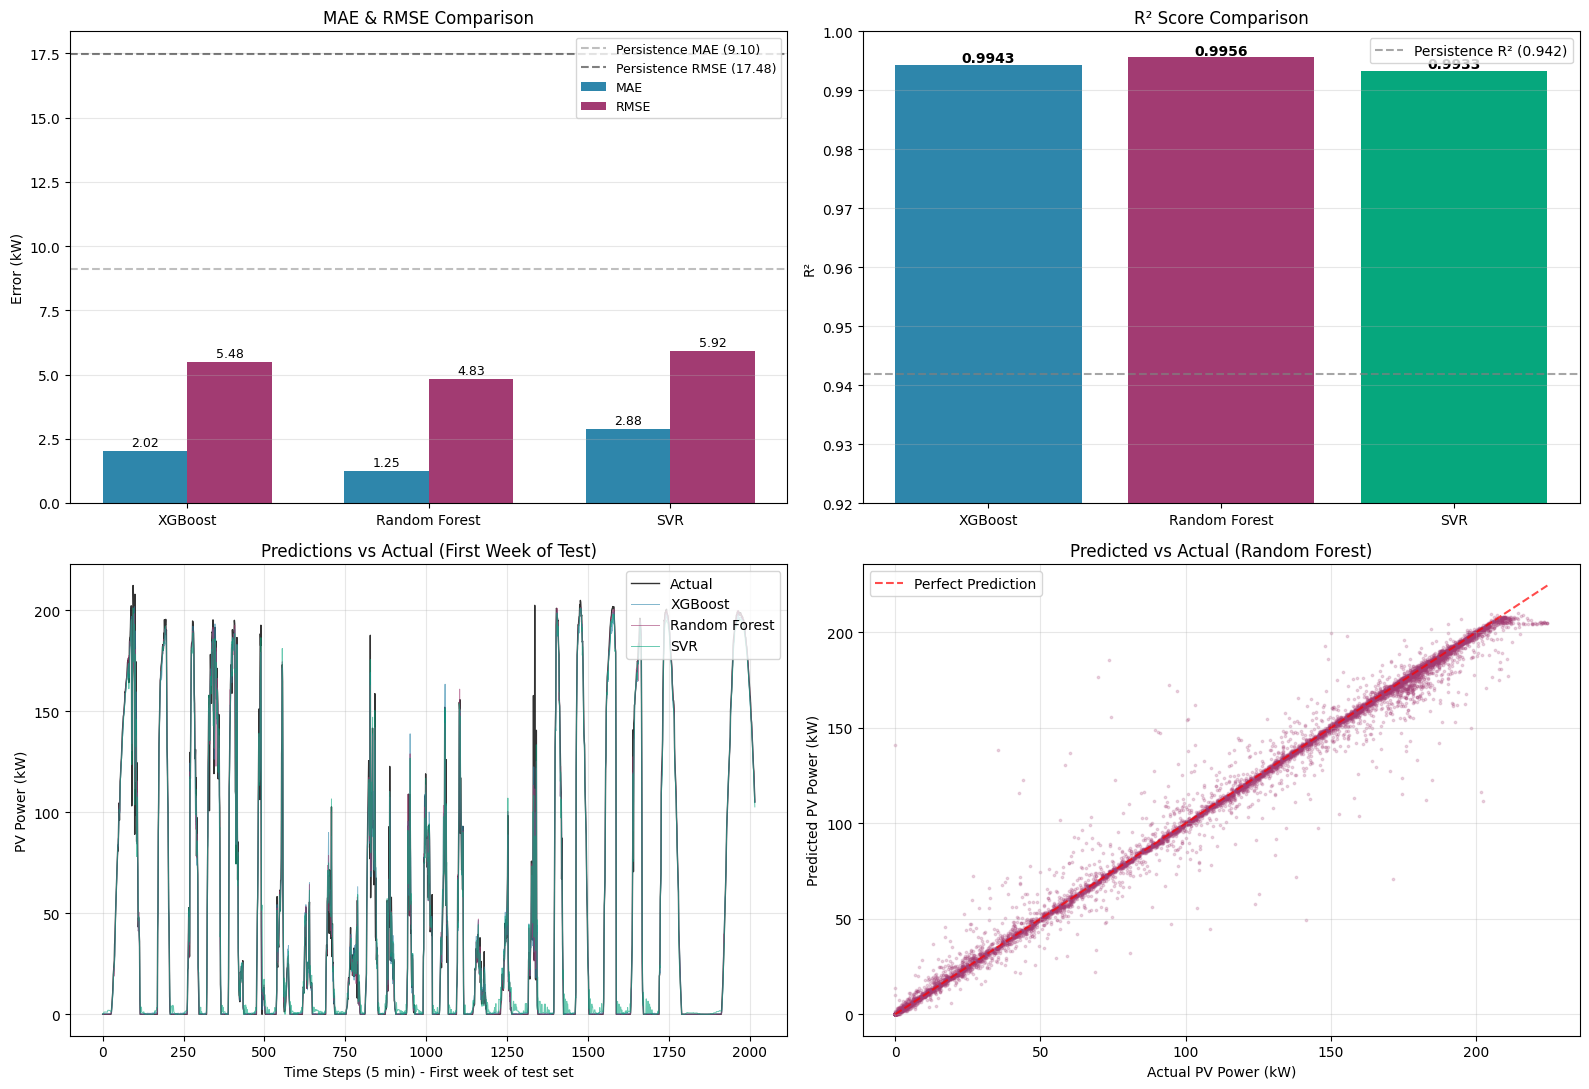


Γράφημα αποθηκεύτηκε: pv_microgrid_comparison.png


In [ ]:
# ============================================================
# CELL 13: COMPARATIVE EVALUATION & PLOTS
# ============================================================

print("="*78)
print(" ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ - PV MICROGRID FORECASTING")
print("="*78)

print(f"\n{'Model':<28} {'MAE (kW)':>12} {'RMSE (kW)':>12} {'R²':>8}")
print(f"{'-'*65}")
print(f"{'Persistence Baseline':<28} {mae_persistence:>12.4f} {rmse_persistence:>12.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<28} {mae_xgb:>12.4f} {rmse_xgb:>12.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<28} {mae_rf:>12.4f} {rmse_rf:>12.4f} {r2_rf:>8.4f}")
print(f"{'SVR (Optimized)':<28} {mae_svr:>12.4f} {rmse_svr:>12.4f} {r2_svr:>8.4f}")

# Best model
results = {
    'XGBoost': {'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R²': r2_xgb,
                'pred': y_pred_xgb_kw},
    'Random Forest': {'MAE': mae_rf, 'RMSE': rmse_rf, 'R²': r2_rf,
                      'pred': y_pred_rf_kw},
    'SVR': {'MAE': mae_svr, 'RMSE': rmse_svr, 'R²': r2_svr,
            'pred': y_pred_svr_kw}
}

best_model = min(results.items(), key=lambda x: x[1]['RMSE'])
print(f"\nBest model (by RMSE): {best_model[0]} (RMSE={best_model[1]['RMSE']:.4f} kW)")

# --- ΟΠΤΙΚΟΠΟΙΗΣΕΙΣ ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

models = ['XGBoost', 'Random Forest', 'SVR']
mae_values = [results[m]['MAE'] for m in models]
rmse_values = [results[m]['RMSE'] for m in models]
r2_values = [results[m]['R²'] for m in models]

colors = ['#2E86AB', '#A23B72', '#06A77D']

# 1. MAE & RMSE Bar chart
ax1 = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, mae_values, width, label='MAE', color='#2E86AB')
ax1.bar(x + width/2, rmse_values, width, label='RMSE', color='#A23B72')
ax1.axhline(y=mae_persistence, color='gray', linestyle='--', alpha=0.5,
            label=f'Persistence MAE ({mae_persistence:.2f})')
ax1.axhline(y=rmse_persistence, color='black', linestyle='--', alpha=0.5,
            label=f'Persistence RMSE ({rmse_persistence:.2f})')
ax1.set_ylabel('Error (kW)')
ax1.set_title('MAE & RMSE Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
for i, (mae, rmse) in enumerate(zip(mae_values, rmse_values)):
    ax1.text(i - width/2, mae + 0.2, f'{mae:.2f}', ha='center', fontsize=9)
    ax1.text(i + width/2, rmse + 0.2, f'{rmse:.2f}', ha='center', fontsize=9)

# 2. R² comparison
ax2 = axes[0, 1]
bars = ax2.bar(models, r2_values, color=colors)
ax2.axhline(y=r2_persistence, color='gray', linestyle='--', alpha=0.7,
            label=f'Persistence R² ({r2_persistence:.3f})')
ax2.set_ylabel('R²')
ax2.set_title('R² Score Comparison')
ax2.set_ylim([0.92, 1.0])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar, r2 in zip(bars, r2_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{r2:.4f}', ha='center', fontsize=10, fontweight='bold')

# 3. Time-series predictions (μία τυπική εβδομάδα)
ax3 = axes[1, 0]
n_plot = 2016  # 1 εβδομάδα (288 timesteps × 7 ημέρες)
ax3.plot(y_test_kw[:n_plot], label='Actual', color='black', linewidth=1, alpha=0.8)
ax3.plot(y_pred_xgb_kw[:n_plot], label='XGBoost', color='#2E86AB',
         alpha=0.6, linewidth=0.7)
ax3.plot(y_pred_rf_kw[:n_plot], label='Random Forest', color='#A23B72',
         alpha=0.6, linewidth=0.7)
ax3.plot(y_pred_svr_kw[:n_plot], label='SVR', color='#06A77D',
         alpha=0.6, linewidth=0.7)
ax3.set_xlabel('Time Steps (5 min) - First week of test set')
ax3.set_ylabel('PV Power (kW)')
ax3.set_title('Predictions vs Actual (First Week of Test)')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# 4. Scatter: Predicted vs Actual (best model)
ax4 = axes[1, 1]
best_pred = best_model[1]['pred']
ax4.scatter(y_test_kw, best_pred, alpha=0.2, s=3, color='#A23B72')
max_val = max(y_test_kw.max(), best_pred.max())
ax4.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='Perfect Prediction')
ax4.set_xlabel('Actual PV Power (kW)')
ax4.set_ylabel('Predicted PV Power (kW)')
ax4.set_title(f'Predicted vs Actual ({best_model[0]})')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pv_microgrid_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nΓράφημα αποθηκεύτηκε: pv_microgrid_comparison.png")

 ERROR ANALYSIS - RANDOM FOREST

--- ERROR DISTRIBUTION ---
Mean error (bias):  -0.2001 kW
Std error:          4.8247 kW
Min error:          -100.63 kW
Max error:          140.94 kW
95th percentile:    5.80 kW
99th percentile:    19.27 kW

--- ERROR BY HOUR OF DAY ---
       MAE  MaxError   AvgPV
Hour                        
0     0.00      0.03    0.00
1     0.00      0.00    0.00
2     0.00      0.00    0.00
3     0.00      0.00    0.00
4     0.00      0.00    0.00
5     0.00      0.00    0.00
6     0.00      0.25    0.00
7     0.63     33.44    8.93
8     1.62     48.64   61.51
9     1.80     48.35  114.00
10    3.33    140.94  150.49
11    3.15     72.08  171.95
12    3.95     76.40  176.24
13    3.93     90.91  171.97
14    3.80    111.94  152.93
15    3.21    103.22  127.29
16    2.76     73.39   83.26
17    1.63     28.50   24.53
18    0.07      3.20    0.46
19    0.00      0.00    0.00
20    0.00      0.00    0.00
21    0.00      0.00    0.00
22    0.00      0.00    0.00
23    

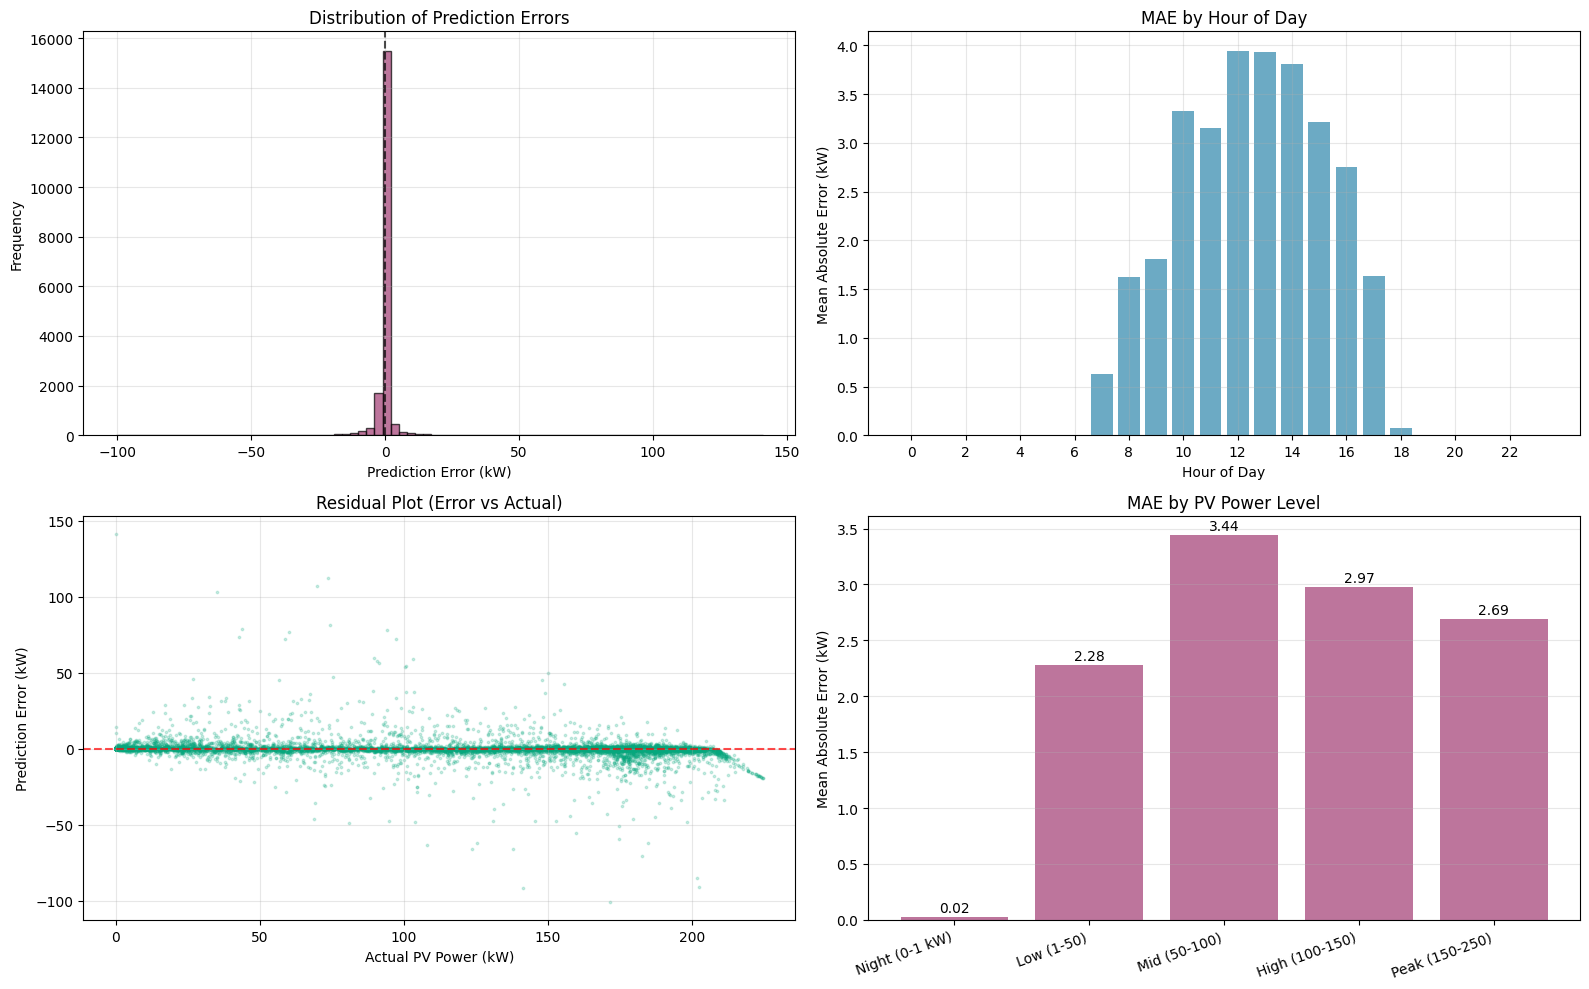


Γράφημα αποθηκεύτηκε: pv_error_analysis.png

 ΣΥΜΠΕΡΑΣΜΑΤΑ ERROR ANALYSIS

1. Mean Bias: -0.200 kW
   (Σχεδόν μηδενικό - το μοντέλο είναι unbiased)

2. Νυχτερινές ώρες: σχεδόν τέλεια πρόβλεψη (MAE ~0)
   Λογικό - το μοντέλο μαθαίνει εύκολα ότι "νύχτα = 0 kW"

3. Peak hours: εδώ συγκεντρώνονται τα μεγαλύτερα σφάλματα
   Λόγος: συννεφιά, transitions ηλιοφάνειας/συννεφιάς

4. 99th percentile error: 19.27 kW
   Το 1% των worst-case predictions είναι σε αυτό το επίπεδο



In [ ]:
# ============================================================
# CELL 14: ERROR ANALYSIS - ΠΟΥ ΚΑΝΕΙ ΛΑΘΗ ΤΟ ΒΕΛΤΙΣΤΟ ΜΟΝΤΕΛΟ
# ============================================================

print("="*70)
print(" ERROR ANALYSIS - RANDOM FOREST")
print("="*70)

# Δημιουργούμε dataframe για analysis
analysis_df = pd.DataFrame({
    'Actual': y_test_kw,
    'Predicted': y_pred_rf_kw,
    'Error': y_pred_rf_kw - y_test_kw,
    'AbsError': np.abs(y_pred_rf_kw - y_test_kw),
    'Hour': test_df.index.hour,
    'Month': test_df.index.month
})

# 1. Error distribution
print(f"\n--- ERROR DISTRIBUTION ---")
print(f"Mean error (bias):  {analysis_df['Error'].mean():+.4f} kW")
print(f"Std error:          {analysis_df['Error'].std():.4f} kW")
print(f"Min error:          {analysis_df['Error'].min():.2f} kW")
print(f"Max error:          {analysis_df['Error'].max():.2f} kW")
print(f"95th percentile:    {analysis_df['AbsError'].quantile(0.95):.2f} kW")
print(f"99th percentile:    {analysis_df['AbsError'].quantile(0.99):.2f} kW")

# 2. Error by Hour
print(f"\n--- ERROR BY HOUR OF DAY ---")
hourly_errors = analysis_df.groupby('Hour').agg({
    'AbsError': ['mean', 'max'],
    'Actual': 'mean'
})
hourly_errors.columns = ['MAE', 'MaxError', 'AvgPV']
print(hourly_errors.round(2).to_string())

# 3. Error by PV Level (πού δυσκολεύεται;)
print(f"\n--- ERROR BY PV LEVEL ---")
pv_bins = [0, 1, 50, 100, 150, 250]
pv_labels = ['Night (0-1 kW)', 'Low (1-50)', 'Mid (50-100)',
             'High (100-150)', 'Peak (150-250)']
analysis_df['PV_Level'] = pd.cut(analysis_df['Actual'], bins=pv_bins,
                                  labels=pv_labels, include_lowest=True)

level_errors = analysis_df.groupby('PV_Level').agg({
    'AbsError': ['mean', 'std', 'count']
})
level_errors.columns = ['MAE', 'STD', 'Count']
print(level_errors.round(2).to_string())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Error histogram
ax1 = axes[0, 0]
ax1.hist(analysis_df['Error'], bins=80, color='#A23B72', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='black', linestyle='--', alpha=0.7)
ax1.set_xlabel('Prediction Error (kW)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Prediction Errors')
ax1.grid(alpha=0.3)

# 2. MAE by hour
ax2 = axes[0, 1]
hourly_mae = analysis_df.groupby('Hour')['AbsError'].mean()
ax2.bar(hourly_mae.index, hourly_mae.values, color='#2E86AB', alpha=0.7)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Mean Absolute Error (kW)')
ax2.set_title('MAE by Hour of Day')
ax2.set_xticks(range(0, 24, 2))
ax2.grid(alpha=0.3)

# 3. Error vs Actual (residual plot)
ax3 = axes[1, 0]
ax3.scatter(analysis_df['Actual'], analysis_df['Error'],
            alpha=0.2, s=3, color='#06A77D')
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax3.set_xlabel('Actual PV Power (kW)')
ax3.set_ylabel('Prediction Error (kW)')
ax3.set_title('Residual Plot (Error vs Actual)')
ax3.grid(alpha=0.3)

# 4. MAE by PV Level
ax4 = axes[1, 1]
level_mae = analysis_df.groupby('PV_Level')['AbsError'].mean()
ax4.bar(range(len(level_mae)), level_mae.values, color='#A23B72', alpha=0.7)
ax4.set_xticks(range(len(level_mae)))
ax4.set_xticklabels(level_mae.index, rotation=20, ha='right')
ax4.set_ylabel('Mean Absolute Error (kW)')
ax4.set_title('MAE by PV Power Level')
ax4.grid(alpha=0.3, axis='y')
for i, v in enumerate(level_mae.values):
    ax4.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pv_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nΓράφημα αποθηκεύτηκε: pv_error_analysis.png")

# Συμπεράσματα
print(f"\n{'='*70}")
print(f" ΣΥΜΠΕΡΑΣΜΑΤΑ ERROR ANALYSIS")
print(f"{'='*70}")
print(f"""
1. Mean Bias: {analysis_df['Error'].mean():+.3f} kW
   (Σχεδόν μηδενικό - το μοντέλο είναι unbiased)

2. Νυχτερινές ώρες: σχεδόν τέλεια πρόβλεψη (MAE ~0)
   Λογικό - το μοντέλο μαθαίνει εύκολα ότι "νύχτα = 0 kW"

3. Peak hours: εδώ συγκεντρώνονται τα μεγαλύτερα σφάλματα
   Λόγος: συννεφιά, transitions ηλιοφάνειας/συννεφιάς

4. 99th percentile error: {analysis_df['AbsError'].quantile(0.99):.2f} kW
   Το 1% των worst-case predictions είναι σε αυτό το επίπεδο
""")

In [ ]:
# ============================================================
# CELL FINAL: SAVE PV MICROGRID RF MODEL
# ============================================================
import pickle

pv_artifacts = {
    'model': rf_model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_cols': feature_cols,
    'target_col': 'PV_Power',
    'target_min': target_min,
    'target_max': target_max,
    'metrics': {
        'MAE': mae_rf,
        'RMSE': rmse_rf,
        'R2': r2_rf
    }
}

save_path = '/content/drive/MyDrive/Final_RUn/pv_microgrid_rf_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(pv_artifacts, f)

print(f"PV Microgrid Random Forest model αποθηκεύτηκε στο:")
print(f"  {save_path}")
print(f"\nDetails:")
print(f"  Features: {len(feature_cols)}")
print(f"  Target range: {target_min:.2f} - {target_max:.2f} kW")
print(f"  Performance: MAE={mae_rf:.2f}, RMSE={rmse_rf:.2f}, R²={r2_rf:.4f}")

PV Microgrid Random Forest model αποθηκεύτηκε στο:
  /content/drive/MyDrive/Final_RUn/pv_microgrid_rf_model.pkl

Details:
  Features: 16
  Target range: 0.00 - 226.87 kW
  Performance: MAE=1.25, RMSE=4.83, R²=0.9956


In [ ]:
# ============================================================
# CELL 17: DAY-AHEAD FEATURE ENGINEERING (PV)
# ============================================================
print("="*70)
print(" DAY-AHEAD FEATURE ENGINEERING (PV)")
print("="*70)

print(f"Source df shape: {df.shape}")
print(f"Source columns: {df.columns.tolist()}")

# === Δημιουργία νέου df_da για day-ahead ===
# Παίρνουμε από το df ΟΛΑ τα διαθέσιμα features:
# - Weather: temperature, humidity, GHI, DHI (Wind δεν υπάρχει στο 5-min)
# - Calendar: hour, month sin/cos
# - PV target: PV_Power
# - Lags: pv_lag_24h ΗΔΗ υπάρχει, θα προσθέσουμε pv_lag_48h, pv_lag_168h

df_da = df[['PV_Power',
            'Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
            'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
            'pv_lag_24h']].copy()

# === Νέα day-ahead lag features ===
STEPS_PER_HOUR = 12
STEPS_48H  = 48 * STEPS_PER_HOUR   # 576
STEPS_168H = 168 * STEPS_PER_HOUR  # 2016

df_da['pv_lag_48h']  = df_da['PV_Power'].shift(STEPS_48H)
df_da['pv_lag_168h'] = df_da['PV_Power'].shift(STEPS_168H)

# === Same-time rolling mean (last 7 days, ίδια χρονική στιγμή) ===
def same_time_rolling_mean(series, n_days, steps_per_day):
    """Average of same time-of-day over last n_days"""
    result = pd.Series(index=series.index, dtype=float)
    for lag in range(1, n_days + 1):
        shifted = series.shift(lag * steps_per_day)
        result = result.add(shifted, fill_value=0)
    return result / n_days

print("\nComputing same-time rolling mean (μπορεί να πάρει 30 sec)...")
df_da['pv_same_time_mean_7d'] = same_time_rolling_mean(
    df_da['PV_Power'], n_days=7, steps_per_day=288
)

# === Rename weather columns για consistency ===
df_da['weather_ghi']         = df_da['Global_Horizontal_Radiation']
df_da['weather_dhi']         = df_da['Diffuse_Horizontal_Radiation']
df_da['weather_temperature'] = df_da['Weather_Temperature_Celsius']
df_da['weather_humidity']    = df_da['Weather_Relative_Humidity']

# Drop NaN από τα lag features
print(f"\nBefore dropna: {df_da.shape}")
df_da = df_da.dropna()
print(f"After dropna:  {df_da.shape}")

# === Final feature list για day-ahead ===
# ΣΗΜΕΙΩΣΗ: Δεν χρησιμοποιούμε Wind Speed γιατί δεν υπάρχει στο 5-min df
DA_FEATURES = [
    # Cyclical calendar
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    # Weather (perfect forecast assumption)
    'weather_ghi', 'weather_dhi', 'weather_temperature', 'weather_humidity',
    # Day-ahead safe lags
    'pv_lag_24h', 'pv_lag_48h', 'pv_lag_168h',
    'pv_same_time_mean_7d',
]

print(f"\n--- DAY-AHEAD FEATURES ({len(DA_FEATURES)}) ---")
for f in DA_FEATURES:
    print(f"  {f}")

df_da_features = df_da.copy()
print(f"\nFinal day-ahead dataset shape: {df_da_features.shape}")

 DAY-AHEAD FEATURE ENGINEERING (PV)
Source df shape: (94216, 17)
Source columns: ['PV_Power', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'pv_lag_5min', 'pv_lag_15min', 'pv_lag_30min', 'pv_lag_1h', 'pv_lag_24h', 'pv_rolling_mean_30min', 'pv_rolling_std_30min', 'pv_rolling_mean_1h']

Computing same-time rolling mean (μπορεί να πάρει 30 sec)...

Before dropna: (94216, 17)
After dropna:  (92200, 17)

--- DAY-AHEAD FEATURES (12) ---
  hour_sin
  hour_cos
  month_sin
  month_cos
  weather_ghi
  weather_dhi
  weather_temperature
  weather_humidity
  pv_lag_24h
  pv_lag_48h
  pv_lag_168h
  pv_same_time_mean_7d

Final day-ahead dataset shape: (92200, 17)


In [ ]:
# ============================================================
# CELL 18: DAY-AHEAD MODEL TRAINING (RF + XGBoost + Persistence)
# ============================================================
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

print("="*70)
print(" DAY-AHEAD MODEL TRAINING (PV)")
print("="*70)

# Train/test split 80/20 χρονικά
n_total = len(df_da_features)
n_train = int(n_total * 0.80)

train_da = df_da_features.iloc[:n_train].copy()
test_da  = df_da_features.iloc[n_train:].copy()

print(f"Train: {len(train_da):,} samples")
print(f"  Range: {train_da.index.min()} to {train_da.index.max()}")
print(f"Test:  {len(test_da):,} samples")
print(f"  Range: {test_da.index.min()} to {test_da.index.max()}")

X_train_da = train_da[DA_FEATURES].values
y_train_da = train_da['PV_Power'].values
X_test_da  = test_da[DA_FEATURES].values
y_test_da  = test_da['PV_Power'].values

# Normalize
scaler_X_da = MinMaxScaler()
scaler_y_da = MinMaxScaler()
X_train_da_n = scaler_X_da.fit_transform(X_train_da)
y_train_da_n = scaler_y_da.fit_transform(y_train_da.reshape(-1, 1)).flatten()
X_test_da_n  = scaler_X_da.transform(X_test_da)

y_da_min = scaler_y_da.data_min_[0]
y_da_max = scaler_y_da.data_max_[0]
y_da_range = y_da_max - y_da_min

# === Random Forest ===
print("\n--- Training Random Forest (day-ahead) ---")
start = time.time()
rf_da_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf_da_model.fit(X_train_da_n, y_train_da_n)
print(f"Time: {time.time()-start:.1f}s")

y_pred_rf_da_n = rf_da_model.predict(X_test_da_n)
y_pred_rf_da = y_pred_rf_da_n * y_da_range + y_da_min
y_pred_rf_da = np.clip(y_pred_rf_da, 0, None)

mae_rf_da  = mean_absolute_error(y_test_da, y_pred_rf_da)
rmse_rf_da = np.sqrt(mean_squared_error(y_test_da, y_pred_rf_da))
r2_rf_da   = 1 - np.sum((y_test_da - y_pred_rf_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"RF day-ahead: MAE={mae_rf_da:.4f} kW, RMSE={rmse_rf_da:.4f} kW, R²={r2_rf_da:.4f}")

# === XGBoost ===
print("\n--- Training XGBoost (day-ahead) ---")
start = time.time()
xgb_da_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_da_model.fit(X_train_da_n, y_train_da_n)
print(f"Time: {time.time()-start:.1f}s")

y_pred_xgb_da_n = xgb_da_model.predict(X_test_da_n)
y_pred_xgb_da = y_pred_xgb_da_n * y_da_range + y_da_min
y_pred_xgb_da = np.clip(y_pred_xgb_da, 0, None)

mae_xgb_da  = mean_absolute_error(y_test_da, y_pred_xgb_da)
rmse_xgb_da = np.sqrt(mean_squared_error(y_test_da, y_pred_xgb_da))
r2_xgb_da   = 1 - np.sum((y_test_da - y_pred_xgb_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"XGB day-ahead: MAE={mae_xgb_da:.4f} kW, RMSE={rmse_xgb_da:.4f} kW, R²={r2_xgb_da:.4f}")

# === Persistence Baseline (yesterday same time) ===
print("\n--- Persistence Baseline ---")
y_pred_persist_da = test_da['pv_lag_24h'].values
y_pred_persist_da = np.clip(y_pred_persist_da, 0, None)

mae_persist_da  = mean_absolute_error(y_test_da, y_pred_persist_da)
rmse_persist_da = np.sqrt(mean_squared_error(y_test_da, y_pred_persist_da))
r2_persist_da   = 1 - np.sum((y_test_da - y_pred_persist_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"Persistence: MAE={mae_persist_da:.4f} kW, RMSE={rmse_persist_da:.4f} kW, R²={r2_persist_da:.4f}")

# === Σύγκριση με 5-min ahead ===
print(f"\n{'='*70}")
print(" PV DAY-AHEAD MODEL COMPARISON")
print(f"{'='*70}")
print(f"{'Model':<25} {'MAE (kW)':<12} {'RMSE (kW)':<12} {'R²':<10}")
print(f"{'-'*59}")
print(f"{'Persistence':<25} {mae_persist_da:<12.4f} {rmse_persist_da:<12.4f} {r2_persist_da:<10.4f}")
print(f"{'Random Forest':<25} {mae_rf_da:<12.4f} {rmse_rf_da:<12.4f} {r2_rf_da:<10.4f}")
print(f"{'XGBoost':<25} {mae_xgb_da:<12.4f} {rmse_xgb_da:<12.4f} {r2_xgb_da:<10.4f}")

# Best model selection
if rmse_rf_da < rmse_xgb_da:
    best_da_model_name = 'Random Forest'
    best_da_pred = y_pred_rf_da
    best_da_mae  = mae_rf_da
    best_da_rmse = rmse_rf_da
    best_da_r2   = r2_rf_da
    best_da_obj  = rf_da_model
else:
    best_da_model_name = 'XGBoost'
    best_da_pred = y_pred_xgb_da
    best_da_mae  = mae_xgb_da
    best_da_rmse = rmse_xgb_da
    best_da_r2   = r2_xgb_da
    best_da_obj  = xgb_da_model

print(f"\n>>> BEST DAY-AHEAD MODEL: {best_da_model_name}")
print(f"    RMSE improvement vs Persistence: {(rmse_persist_da - best_da_rmse)/rmse_persist_da*100:+.1f}%")

# Σύγκριση με 5-min ahead (από τα προηγούμενα cells)
print(f"\n--- ΣΥΓΚΡΙΣΗ 5-MIN AHEAD vs DAY-AHEAD ---")
print(f"5-min ahead RF:  MAE={mae_rf:.4f}, RMSE={rmse_rf:.4f}")
print(f"Day-ahead {best_da_model_name}: MAE={best_da_mae:.4f}, RMSE={best_da_rmse:.4f}")
print(f"Η διαφορά είναι αναμενόμενη: day-ahead είναι πολύ πιο δύσκολο πρόβλημα.")

 DAY-AHEAD MODEL TRAINING (PV)
Train: 73,760 samples
  Range: 2024-03-09 00:35:00 to 2025-03-19 12:30:00
Test:  18,440 samples
  Range: 2025-03-19 12:40:00 to 2025-09-04 11:40:00

--- Training Random Forest (day-ahead) ---
Time: 131.3s
RF day-ahead: MAE=4.1843 kW, RMSE=12.1120 kW, R²=0.9720

--- Training XGBoost (day-ahead) ---
Time: 8.7s
XGB day-ahead: MAE=4.4102 kW, RMSE=11.8556 kW, R²=0.9732

--- Persistence Baseline ---
Persistence: MAE=5.8761 kW, RMSE=19.1369 kW, R²=0.9301

 PV DAY-AHEAD MODEL COMPARISON
Model                     MAE (kW)     RMSE (kW)    R²        
-----------------------------------------------------------
Persistence               5.8761       19.1369      0.9301    
Random Forest             4.1843       12.1120      0.9720    
XGBoost                   4.4102       11.8556      0.9732    

>>> BEST DAY-AHEAD MODEL: XGBoost
    RMSE improvement vs Persistence: +38.0%

--- ΣΥΓΚΡΙΣΗ 5-MIN AHEAD vs DAY-AHEAD ---
5-min ahead RF:  MAE=1.2497, RMSE=4.8287
Day-ahead 

In [ ]:
# ============================================================
# CELL 19 (CPU): SAVE PREDICTIONS FOR EMS
# ============================================================
import os, json

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
os.makedirs(SAVE_DIR, exist_ok=True)

# === 5-min ahead predictions (Random Forest is best από Cell 11) ===
df_pred_5min = pd.DataFrame({
    'actual':    y_test_kw,
    'predicted': y_pred_rf_kw,
})
df_pred_5min.to_csv(SAVE_DIR + 'pv_5min_predictions_cpu.csv', index=False)
print(f"Saved: pv_5min_predictions_cpu.csv ({len(df_pred_5min)} rows)")

# === Day-ahead predictions (XGBoost is best) ===
df_pred_24h = pd.DataFrame({
    'timestamp':         test_da.index,
    'actual':            y_test_da,
    'predicted_rf':      y_pred_rf_da,
    'predicted_xgb':     y_pred_xgb_da,
    'predicted_persist': y_pred_persist_da,
    'predicted_best':    best_da_pred,
})
df_pred_24h['best_model'] = best_da_model_name
df_pred_24h.to_csv(SAVE_DIR + 'pv_24h_predictions_cpu.csv', index=False)
print(f"Saved: pv_24h_predictions_cpu.csv ({len(df_pred_24h)} rows)")

# === Save day-ahead model artifacts (για να ξανατρέξεις το EMS όποτε θες) ===
import pickle
da_artifacts = {
    'model':        best_da_obj,
    'scaler_X':     scaler_X_da,
    'scaler_y':     scaler_y_da,
    'feature_cols': DA_FEATURES,
    'target_min':   y_da_min,
    'target_max':   y_da_max,
    'model_name':   best_da_model_name,
    'metrics':      {'MAE': best_da_mae, 'RMSE': best_da_rmse, 'R2': best_da_r2},
}
with open('/content/drive/MyDrive/Final_RUn/pv_microgrid_day_ahead_cpu.pkl', 'wb') as f:
    pickle.dump(da_artifacts, f)
print(f"Saved: pv_microgrid_day_ahead_cpu.pkl")

# === Metrics summary ===
metrics_summary = {
    'PV_5min_ML': {
        'best_model': 'Random Forest',
        'MAE':  float(mae_rf),
        'RMSE': float(rmse_rf),
        'all_models': {
            'RF':       {'MAE': float(mae_rf),  'RMSE': float(rmse_rf)},
            'XGBoost':  {'MAE': float(mae_xgb), 'RMSE': float(rmse_xgb)},
            'SVR':      {'MAE': float(mae_svr), 'RMSE': float(rmse_svr)},
            'Persistence': {'MAE': float(mae_persistence), 'RMSE': float(rmse_persistence)},
        }
    },
    'PV_24h': {
        'best_model':       best_da_model_name,
        'MAE':              float(best_da_mae),
        'RMSE':             float(best_da_rmse),
        'R2':               float(best_da_r2),
        'persistence_RMSE': float(rmse_persist_da),
        'all_models': {
            'RF':          {'MAE': float(mae_rf_da),  'RMSE': float(rmse_rf_da)},
            'XGBoost':     {'MAE': float(mae_xgb_da), 'RMSE': float(rmse_xgb_da)},
            'Persistence': {'MAE': float(mae_persist_da), 'RMSE': float(rmse_persist_da)},
        }
    }
}
with open(SAVE_DIR + 'pv_metrics_cpu.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(f"Saved: pv_metrics_cpu.json")

print(f"\n{'='*70}")
print(" PV CPU notebook complete!")
print(f"{'='*70}")

Saved: pv_5min_predictions_cpu.csv (18844 rows)
Saved: pv_24h_predictions_cpu.csv (18440 rows)
Saved: pv_microgrid_day_ahead_cpu.pkl
Saved: pv_metrics_cpu.json

 PV CPU notebook complete!


Hourly rows: 3727
Range: 2025-03-19 12:00:00 -> 2025-09-04 11:00:00

Επιλεγμένες ηλιόλουστες ημέρες:
  2025-04-08 - max PV: 198.9 kW στις 12:00
  2025-04-09 - max PV: 193.7 kW στις 13:00
  2025-04-10 - max PV: 196.9 kW στις 12:00

✓ Saved: /content/drive/MyDrive/Final_RUn/pv_da_cpu_3days.png


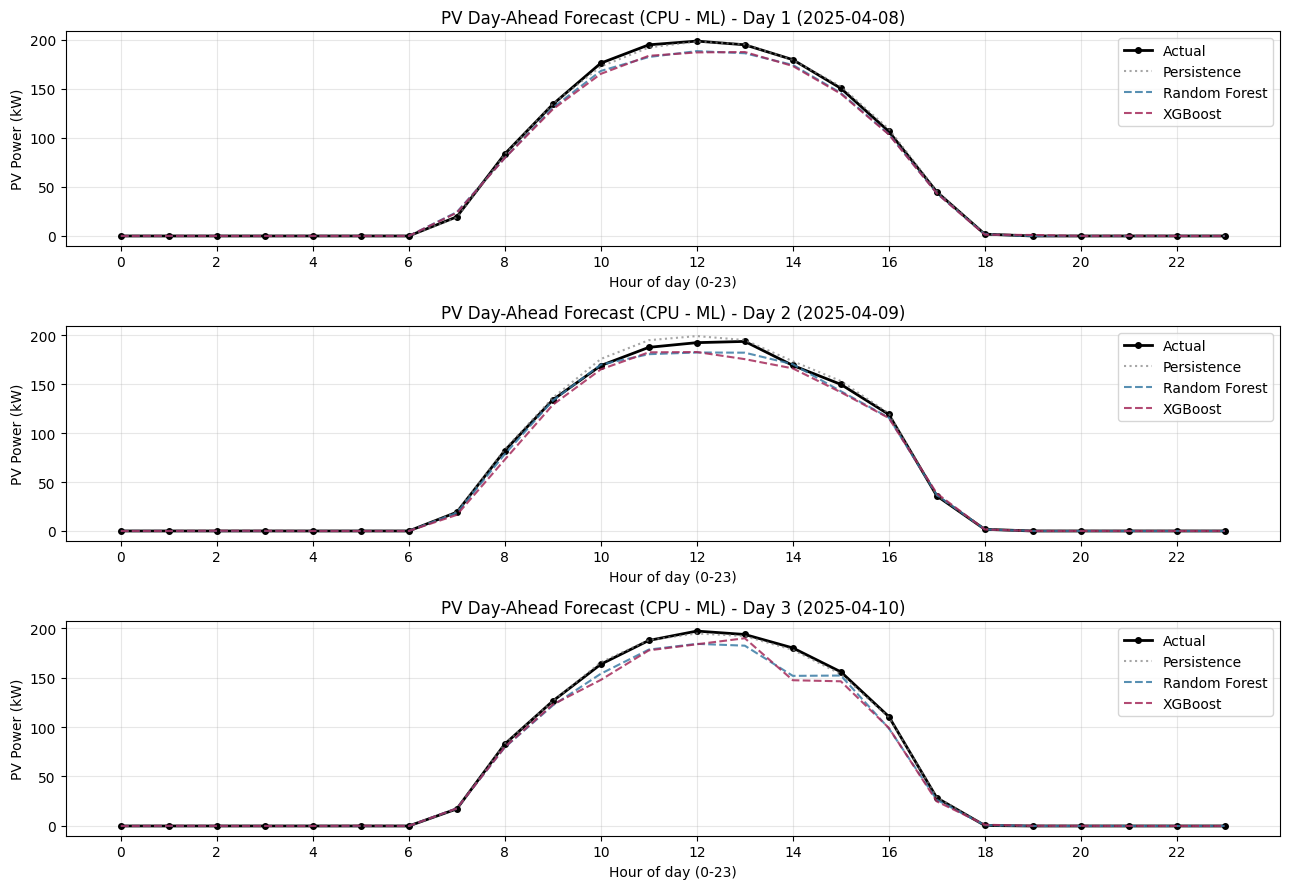

In [ ]:
# ============================================================
# CELL: PV CPU Day-Ahead - 3 ηλιόλουστες ημέρες
# Τα timestamps είναι ΗΔΗ σε Alice Springs local time
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

pv_cpu = pd.read_csv(PRED_DIR + 'pv_24h_predictions_cpu.csv')
pv_cpu['timestamp'] = pd.to_datetime(pv_cpu['timestamp'])
pv_cpu = pv_cpu.set_index('timestamp').sort_index()

# ΔΕΝ κάνουμε timezone conversion - τα data είναι ήδη local time

# Resample σε ωριαία
pv_cpu_h = pv_cpu.select_dtypes(include=[np.number]).resample('1h').mean().dropna()
print(f"Hourly rows: {len(pv_cpu_h)}")
print(f"Range: {pv_cpu_h.index.min()} -> {pv_cpu_h.index.max()}")

# === Βρίσκουμε 3 ηλιόλουστες ημέρες ===
day_starts_at_midnight = pv_cpu_h[pv_cpu_h.index.hour == 0].index
SUNNY_THRESHOLD = 150
sunny_starts = []

for day_start_ts in day_starts_at_midnight:
    day_slice = pv_cpu_h.loc[day_start_ts : day_start_ts + pd.Timedelta(hours=23)]
    if len(day_slice) == 24 and day_slice['actual'].max() > SUNNY_THRESHOLD:
        sunny_starts.append(day_start_ts)
    if len(sunny_starts) >= 3:
        break

print(f"\nΕπιλεγμένες ηλιόλουστες ημέρες:")
for s in sunny_starts:
    d = pv_cpu_h.loc[s : s + pd.Timedelta(hours=23)]
    print(f"  {s.strftime('%Y-%m-%d')} - max PV: {d['actual'].max():.1f} kW στις {d['actual'].idxmax().hour:02d}:00")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    if i >= len(sunny_starts):
        break
    start_ts = sunny_starts[i]
    sub = pv_cpu_h.loc[start_ts : start_ts + pd.Timedelta(hours=23)]
    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',        marker='o', markersize=4)
    ax.plot(hours, sub['predicted_persist'].values, ':',   lw=1.5, label='Persistence',   alpha=0.7,  color='gray')
    ax.plot(hours, sub['predicted_rf'].values,      '--',  lw=1.5, label='Random Forest', alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_xgb'].values,     '--',  lw=1.5, label='XGBoost',       alpha=0.85, color='#a52a5a')

    ax.set_title(f'PV Day-Ahead Forecast (CPU - ML) - Day {i+1} ({day_label})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('PV Power (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'pv_da_cpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()